<div style="background:linear-gradient(135deg,#78350f 0%,#b45309 55%,#f59e0b 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 166 &middot; Capstone 7 &middot; Two-Way ANOVA</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Does the Fertilizer Work? It Depends.</div>
  <div style="font-size:15px;color:#fef3c7;max-width:800px;line-height:1.6">Two factors at once, fertilizer and light, on plant growth. The point of a factorial design is the question neither factor can answer alone: does the effect of one depend on the level of the other? When the answer is yes, the main effects stop meaning what they seem to.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
GOLD, DARK, BL, RD, GR, MUT = "#b45309", "#78350f", "#2563eb", "#dc2626", "#16a34a", "#94a3b8"
LIGHT = ["Low","Medium","High"]; FERT = ["Standard","Premium"]
COL = {"Standard": MUT, "Premium": GOLD}

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-plant-growth-two-factors.xlsx"
try: raw = pd.read_excel("../../data/" + fn, sheet_name="plants")
except FileNotFoundError: raw = pd.read_excel(BASE + fn, sheet_name="plants")
print("loaded", raw.shape[0], "rows")
raw.head()

loaded 74 rows


,plant_id,fertilizer,light,growth_cm
0,PL446,Premium,low,12.0
1,PL465,Premium,high,34.1
2,PL449,Premium,medium,24.8
3,PL426,Standard,high,23.4
4,PL427,Standard,High,27.9


## Step 1 &middot; Goal and hypotheses
A greenhouse trial crossed **two fertilizers** (Standard, Premium) with **three light levels** (Low, Medium, High), growing twelve plants in each of the six combinations. Growth was measured in centimetres. The trial asks three questions at once, and the third is the reason to run it this way.

A two-way ANOVA tests three null hypotheses in a single model.
- **H&#8320; (fertilizer):** the two fertilizers give the same mean growth, averaging over light.
- **H&#8320; (light):** the three light levels give the same mean growth, averaging over fertilizer.
- **H&#8320; (interaction):** the effect of fertilizer is the **same at every light level**.

That third hypothesis is what a factorial design buys. Running two separate one-way ANOVAs would answer the first two and never even ask the third.

## Step 2 &middot; Know the data types
The outcome, `growth_cm`, is **continuous**. There are **two nominal factors**: `fertilizer` with two levels and `light` with three, fully crossed, giving six treatment cells. A continuous outcome across two crossed factors is the home of the **two-way (factorial) ANOVA**.

In [2]:
print(raw.dtypes)
print("\nfertilizer labels as they arrived:"); print(raw.fertilizer.value_counts().to_string())
print("\nlight labels as they arrived:"); print(raw.light.value_counts().to_string())

plant_id          str
fertilizer        str
light             str
growth_cm     float64
dtype: object

fertilizer labels as they arrived:
fertilizer
Premium      16
Standard     15
Standard     14
Premium      12
premium       9
standard      8

light labels as they arrived:
light
medium    17
low       16
high      15
High       9
Low        9
Medium     8


**What this shows.** Both factor labels arrived inconsistently cased and spaced, so each would be read as more levels than it really has. Standardizing both is the first cleaning job, before any cell can be counted correctly.

## Step 3 &middot; Describe

In [3]:
print("rows:", len(raw), " unique plants:", raw.plant_id.nunique())
print("\nraw growth_cm summary:")
print(raw.growth_cm.describe().round(2).to_string())

rows: 74  unique plants: 72

raw growth_cm summary:
count     72.00
mean      27.88
std       27.59
min       -3.00
25%       20.15
50%       24.80
75%       30.12
max      250.00


**What this shows.** More rows than plants means duplicate log entries, and the range extends below zero and far above any plausible growth, so there are impossible values to remove before the cell means can be trusted.

## Step 4 &middot; Prepare and clean
Standardize both factor labels, then drop **duplicate rows**, **missing values**, and **impossible growth** (outside 0 to 100 cm).

In [4]:
df = raw.copy()
df["fertilizer"] = df.fertilizer.str.strip().str.title()
df["light"] = df.light.str.strip().str.title()
before = len(df)
df = df.drop_duplicates(); a_dup = len(df)
df = df.dropna(subset=["growth_cm"]); a_na = len(df)
bad = df[~df.growth_cm.between(0,100)]
df = df[df.growth_cm.between(0,100)].copy()
print("fertilizer levels:", sorted(df.fertilizer.unique()), " light levels:", sorted(df.light.unique()))
print(f"start {before}  ->  dedup {a_dup} (-{before-a_dup})  ->  dropna {a_na} (-{a_dup-a_na})")
print("impossible values removed:", sorted(bad.growth_cm.tolist()))
print(f"clean analysis sample: n = {len(df)}")
print()
cells = df.groupby(["light","fertilizer"]).growth_cm.agg(["count","mean","std"]).round(2)
print(cells.reindex(pd.MultiIndex.from_product([LIGHT,FERT], names=["light","fertilizer"])).to_string())

fertilizer levels: ['Premium', 'Standard']  light levels: ['High', 'Low', 'Medium']
start 74  ->  dedup 72 (-2)  ->  dropna 70 (-2)
impossible values removed: [-3.0, 250.0]
clean analysis sample: n = 68

                   count   mean   std
light  fertilizer                    
Low    Standard        9  18.41  3.83
       Premium        12  17.36  3.55
Medium Standard       12  24.99  3.00
       Premium        12  27.30  3.15
High   Standard       12  27.65  2.92
       Premium        11  35.33  3.44


**Read the cell means, not the margins.** Look along the light levels. At **Low** light the two fertilizers are the same, within about a centimetre, and Premium is if anything slightly behind. At **Medium** Premium is a couple of centimetres ahead. At **High** Premium is nearly **eight centimetres** ahead. The gap between fertilizers is not constant, it grows with light, which is precisely what an interaction is.

## Step 5 &middot; Visualize: the interaction plot
For a factorial design the essential picture is the **interaction plot**: one line per level of one factor, drawn across the levels of the other. **Parallel lines mean no interaction.** Lines that converge, diverge, or cross mean the effect of one factor depends on the other.

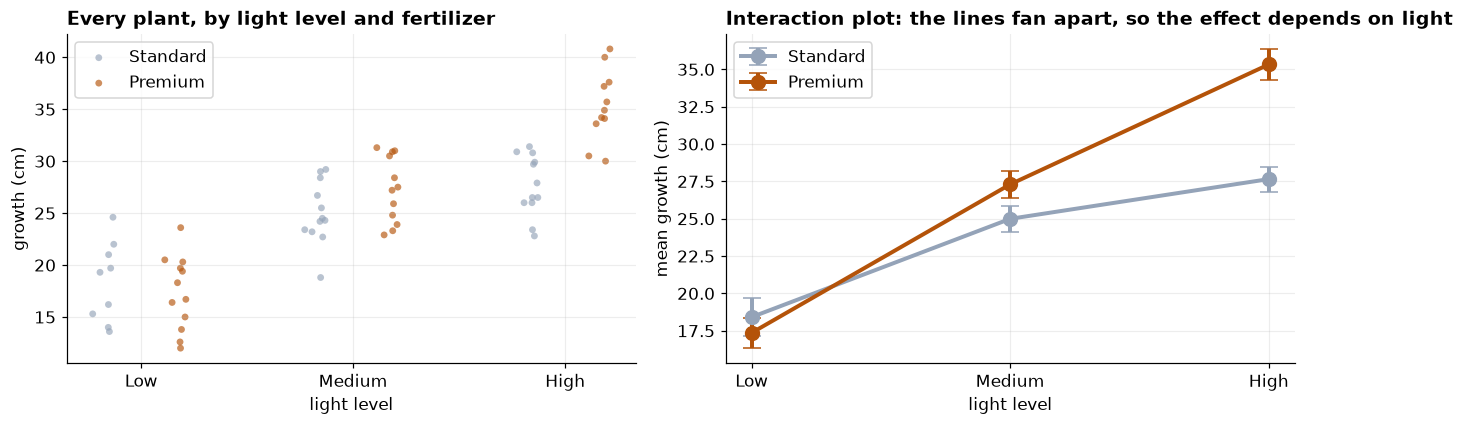

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# (a) cell distributions
pos = {"Standard":-0.17, "Premium":0.17}
for f in FERT:
    xs, ys = [], []
    for i, l in enumerate(LIGHT):
        v = df[(df.light==l)&(df.fertilizer==f)].growth_cm.values
        xs += list(np.random.default_rng(1).normal(i+pos[f], 0.045, len(v))); ys += list(v)
    ax[0].scatter(xs, ys, s=20, alpha=0.65, color=COL[f], label=f, edgecolor="none")
ax[0].set_xticks(range(3)); ax[0].set_xticklabels(LIGHT); ax[0].set_xlabel("light level")
ax[0].set_ylabel("growth (cm)"); ax[0].set_title("Every plant, by light level and fertilizer"); ax[0].legend()
# (b) interaction plot
for f in FERT:
    m = [df[(df.light==l)&(df.fertilizer==f)].growth_cm.mean() for l in LIGHT]
    e = [stats.sem(df[(df.light==l)&(df.fertilizer==f)].growth_cm) for l in LIGHT]
    ax[1].errorbar(LIGHT, m, yerr=e, marker="o", markersize=9, lw=2.6, capsize=6,
                   color=COL[f], label=f)
ax[1].set_xlabel("light level"); ax[1].set_ylabel("mean growth (cm)")
ax[1].set_title("Interaction plot: the lines fan apart, so the effect depends on light"); ax[1].legend()
plt.tight_layout(); plt.show()

**Reading the interaction plot.** The two lines start together at Low light and **fan apart** as light increases. If fertilizer had a constant benefit the lines would be parallel; if fertilizer did nothing they would sit on top of each other. Neither is true here. The visual already answers the question the formal test is about to confirm, and it also warns that any single number summarizing "the fertilizer effect" will be misleading.

## Step 6 &middot; Name the design
Two crossed factors, one with two levels and one with three, with twelve plants per cell: a **2 &#215; 3 between-subjects factorial** design. Every plant appears in exactly one cell, so the groups are independent. Because both factors are crossed, the model can estimate two **main effects** and their **interaction**.

## Step 7 &middot; Check the assumptions
A factorial ANOVA asks for the same conditions as the one-way case, applied to the model: the **residuals** should be roughly normal, and the variance should be similar **across all six cells**. We fit the model first, then check what it leaves behind.

Shapiro-Wilk on residuals : W = 0.972, p = 0.123  -> normal enough
Levene across the 6 cells : W = 0.341, p = 0.8859  -> equal variances

cell standard deviations:
light   fertilizer
High    Premium       3.44
        Standard      2.92
Low     Premium       3.55
        Standard      3.83
Medium  Premium       3.15
        Standard      3.00


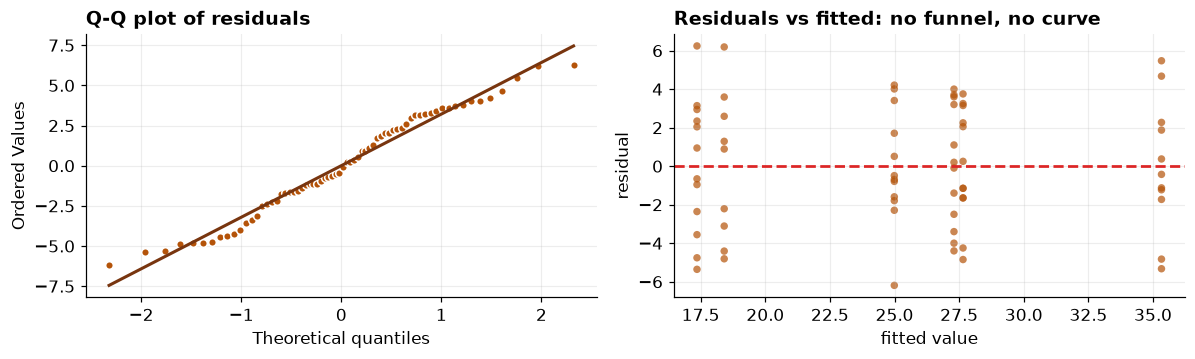

In [6]:
model = ols("growth_cm ~ C(fertilizer)*C(light)", data=df).fit()
sw = stats.shapiro(model.resid)
cells_list = [g.values for _, g in df.groupby(["fertilizer","light"]).growth_cm]
lev = stats.levene(*cells_list)
print(f"Shapiro-Wilk on residuals : W = {sw.statistic:.3f}, p = {sw.pvalue:.3f}  -> {'normal enough' if sw.pvalue>0.05 else 'not normal'}")
print(f"Levene across the 6 cells : W = {lev.statistic:.3f}, p = {lev.pvalue:.4f}  -> {'equal variances' if lev.pvalue>0.05 else 'variances differ'}")
print("\ncell standard deviations:")
print(df.groupby(["light","fertilizer"]).growth_cm.std().round(2).to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
stats.probplot(model.resid, dist="norm", plot=ax[0])
ax[0].get_lines()[0].set(marker="o", markerfacecolor=GOLD, markeredgecolor="white", markersize=5)
ax[0].get_lines()[1].set(color=DARK, lw=2); ax[0].set_title("Q-Q plot of residuals")
ax[1].scatter(model.fittedvalues, model.resid, s=24, alpha=0.7, color=GOLD, edgecolor="none")
ax[1].axhline(0, color=RD, lw=1.8, ls="--")
ax[1].set_xlabel("fitted value"); ax[1].set_ylabel("residual")
ax[1].set_title("Residuals vs fitted: no funnel, no curve")
plt.tight_layout(); plt.show()

**What the diagnostics say.** The residuals track the Q-Q line and Shapiro-Wilk does not reject normality. The six cell standard deviations sit in a narrow band and Levene is comfortably non-significant, so equal variance holds. The residuals-versus-fitted plot shows no funnel shape (which would signal variance growing with the mean) and no curvature (which would signal a missing term). The model is sound, so we can read its ANOVA table.

## Step 8 &middot; Decide, and the order that matters
Assumptions hold, so we use the standard factorial ANOVA with **Type II sums of squares**, appropriate here because the design is nearly balanced. The critical decision rule in a factorial analysis is about **reading order**: look at the **interaction first**. If it is significant, the main effects can no longer be interpreted on their own, because "the effect of fertilizer" is not a single number, it is a different number at each light level.

## Step 9 &middot; Choose the tests
- **Primary:** two-way ANOVA testing both main effects and the interaction.
- **If the interaction is significant:** **simple effects**, the fertilizer contrast computed separately within each light level, which is the only honest way to describe the fertilizer effect.
- **Reported alongside:** partial eta-squared for each term.

## Step 10 &middot; Run the model

In [7]:
aov = sm.stats.anova_lm(model, typ=2)
print(aov.round(4).to_string())
ss = aov["sum_sq"]; resid_ss = ss["Residual"]
print("\npartial eta-squared:")
for term in aov.index[:-1]:
    pe = ss[term]/(ss[term]+resid_ss)
    label = {"C(fertilizer)":"fertilizer (main)","C(light)":"light (main)",
             "C(fertilizer):C(light)":"fertilizer x light (interaction)"}[term]
    print(f"  {label:34s} {pe:.4f}")

                           sum_sq    df        F  PR(>F)
C(fertilizer)            163.2445   1.0  14.9553  0.0003
C(light)                2106.6069   2.0  96.4964  0.0000
C(fertilizer):C(light)   212.6933   2.0   9.7427  0.0002
Residual                 676.7590  62.0      NaN     NaN

partial eta-squared:
  fertilizer (main)                  0.1943
  light (main)                       0.7569
  fertilizer x light (interaction)   0.2391


**Reading the table, interaction first.** The **interaction is significant** (p = 0.0002, partial eta-squared 0.24). That is the headline, and it changes how everything above it is read. Light has an enormous main effect (partial eta-squared 0.76) and fertilizer a significant one (0.19), but the fertilizer main effect is now a **weighted average of three different fertilizer effects**, one per light level, and reporting it alone would tell a gardener something false.

In [8]:
print("SIMPLE EFFECTS: Premium minus Standard, computed within each light level\n")
rows = []
for l in LIGHT:
    a = df[(df.light==l)&(df.fertilizer=="Standard")].growth_cm
    b = df[(df.light==l)&(df.fertilizer=="Premium")].growth_cm
    t, p = stats.ttest_ind(b, a, equal_var=False)
    d = (b.mean()-a.mean())/np.sqrt((a.var(ddof=1)+b.var(ddof=1))/2)
    rows.append([l, len(a), len(b), b.mean()-a.mean(), t, p, d])
    print(f"  {l:7s} n={len(a)}/{len(b)}  difference = {b.mean()-a.mean():+6.2f} cm   t = {t:6.2f}   p = {p:.4f}   d = {d:+.2f}")
print("\nthe fertilizer effect is not one number; it is three, and only one of them matters.")

SIMPLE EFFECTS: Premium minus Standard, computed within each light level

  Low     n=9/12  difference =  -1.05 cm   t =  -0.64   p = 0.5293   d = -0.28
  Medium  n=12/12  difference =  +2.31 cm   t =   1.84   p = 0.0799   d = +0.75
  High    n=12/11  difference =  +7.68 cm   t =   5.75   p = 0.0000   d = +2.41

the fertilizer effect is not one number; it is three, and only one of them matters.


**Reading the simple effects.** At **Low** light Premium is not better at all (about one centimetre behind, p = 0.53). At **Medium** light it is about two centimetres ahead, which does not reach significance on its own (p = 0.08). At **High** light it is nearly **eight centimetres** ahead, decisively (p &lt; 0.0001, a very large effect). So the honest description is not "Premium fertilizer increases growth", it is **"Premium fertilizer increases growth only when light is plentiful"**.

## Step 11 &middot; Estimate, do not just test
The interaction told us the fertilizer effect depends on light. The simple effects told us the direction at each level. Intervals tell us the size, and they change what can be promised to a grower.

In [9]:
# A percentile bootstrap: resample the data with replacement, recompute, repeat.
# Chapter 73 introduced this; it is how we get an interval when no formula exists.
def boot_ci(data, stat, B=10000, seed=11, ci=95):
    rng = np.random.default_rng(seed)
    data = np.asarray(data)
    reps = np.array([stat(rng.choice(data, size=len(data), replace=True)) for _ in range(B)])
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

def boot_ci_pairs(a, b, stat, B=10000, seed=11, ci=95):
    """Bootstrap for two paired/related arrays: resample ROW indices together."""
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a), np.asarray(b)
    idx = np.arange(len(a))
    reps = np.array([stat(a[i], b[i]) for i in
                     (rng.choice(idx, size=len(idx), replace=True) for _ in range(B))])
    reps = reps[np.isfinite(reps)]
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

def boot_ci_groups(groups, stat, B=10000, seed=11, ci=95):
    """Bootstrap for k independent groups: resample within each group."""
    rng = np.random.default_rng(seed)
    groups = [np.asarray(g) for g in groups]
    reps = []
    for _ in range(B):
        rs = [rng.choice(g, size=len(g), replace=True) for g in groups]
        v = stat(rs)
        if np.isfinite(v):
            reps.append(v)
    reps = np.array(reps)
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

print(f"{'light level':12s} {'Premium minus Standard':>24s}  {'95% CI':>18s}   verdict")
print("-"*78)
for L in LIGHT:
    a = df[(df.light==L) & (df.fertilizer=="Premium")].growth_cm.values
    b = df[(df.light==L) & (df.fertilizer=="Standard")].growth_cm.values
    diff_ = a.mean() - b.mean()
    se = np.sqrt(a.var(ddof=1)/len(a) + b.var(ddof=1)/len(b))
    dof = (a.var(ddof=1)/len(a) + b.var(ddof=1)/len(b))**2 / (
          (a.var(ddof=1)/len(a))**2/(len(a)-1) + (b.var(ddof=1)/len(b))**2/(len(b)-1))
    crit = stats.t.ppf(0.975, dof)
    l_, h_ = diff_ - crit*se, diff_ + crit*se
    print(f"{L:12s} {diff_:+24.2f}  [{l_:+6.2f}, {h_:+6.2f}]   "
          f"{'premium pays' if l_ > 0 else 'cannot separate'}")

# An interval for the interaction effect size.
ss_int = aov.loc["C(fertilizer):C(light)","sum_sq"]
pe_int = ss_int/(ss_int + resid_ss)
cellgroups = [df[(df.light==L)&(df.fertilizer=="F")].growth_cm.values for L in LIGHT for F in FERT]
cellgroups = [df[(df.light==L)&(df.fertilizer==F)].growth_cm.values for L in LIGHT for F in FERT]
def _pe(g):
    lab = [(L,F) for L in LIGHT for F in FERT]
    d2 = pd.DataFrame({"growth_cm": np.concatenate(g),
                       "light": np.repeat([l for l,_ in lab], [len(x) for x in g]),
                       "fertilizer": np.repeat([f for _,f in lab], [len(x) for x in g])})
    a2 = sm.stats.anova_lm(ols("growth_cm ~ C(fertilizer)*C(light)", data=d2).fit(), typ=2)
    return a2.loc["C(fertilizer):C(light)","sum_sq"]/(a2.loc["C(fertilizer):C(light)","sum_sq"]+a2.loc["Residual","sum_sq"])
pi_lo, pi_hi, _ = boot_ci_groups(cellgroups, _pe, B=2000, seed=5)
print(f"\npartial eta-squared, interaction  {pe_int:.3f}   95% CI [{pi_lo:.3f}, {pi_hi:.3f}]")

light level    Premium minus Standard              95% CI   verdict
------------------------------------------------------------------------------
Low                             -1.05  [ -4.52,  +2.41]   cannot separate
Medium                          +2.31  [ -0.30,  +4.92]   cannot separate
High                            +7.68  [ +4.89, +10.47]   premium pays



partial eta-squared, interaction  0.239   95% CI [0.106, 0.437]


**What a grower can actually be told.** Under high light, premium fertilizer adds between about 4.9 and 10.5 cm, so it pays and the only question is how much. Under low light the interval runs from roughly &#8722;4.5 to +2.4 cm: the data are compatible with premium being slightly worse. Under medium light the interval straddles zero but leans positive.

That is the interaction expressed as three decisions rather than one significance test. **Buy premium for the bright benches; do not buy it for the dim ones.** No single averaged number could have carried that message, which is exactly why reading the main effect first would have been the wrong move.

## Step 12 &middot; The one capstone where "caused" is the right word
Almost every chapter in this part ends by warning against causal language. This one does not, and it is worth being explicit about why the difference is in the **design**, not in the statistics.

In [10]:
print("What this study did that the observational capstones did not:\n")
print("  1. The experimenter SET the levels of light and fertilizer.")
print("     They were assigned, not observed as they happened to occur.")
print("  2. Plants were ALLOCATED to the six combinations rather than self-selecting.")
print("     Any pre-existing difference between plants is spread across cells by chance.")
print("  3. Everything else was held constant: same greenhouse, same water, same period.\n")
print(df.groupby(["light","fertilizer"]).growth_cm.count().rename("plants per cell").to_string())
print("\nBecause treatment was assigned, the ONLY systematic difference between cells")
print("is the treatment itself. That is what licenses the word 'caused'.")

What this study did that the observational capstones did not:

  1. The experimenter SET the levels of light and fertilizer.
     They were assigned, not observed as they happened to occur.
  2. Plants were ALLOCATED to the six combinations rather than self-selecting.
     Any pre-existing difference between plants is spread across cells by chance.
  3. Everything else was held constant: same greenhouse, same water, same period.

light   fertilizer
High    Premium       11
        Standard      12
Low     Premium       12
        Standard       9
Medium  Premium       12
        Standard      12

Because treatment was assigned, the ONLY systematic difference between cells
is the treatment itself. That is what licenses the word 'caused'.


**Manipulation is what buys causal language.** In <a href="../chapters/capstone-study-hours-and-scores.html">Capstone 11</a> we measured study hours as students happened to report them, so a correlation could reflect hours causing scores, ease causing hours, or prior ability causing both. Here the experimenter **assigned** the light level and the fertilizer. Plants did not choose the bright bench, and a plant's own vigour cannot have influenced which treatment it received.

That single design feature closes off the alternatives. Reverse causation is impossible, since growth cannot reach back and change the fertilizer applied last month. Confounding is controlled by allocation, since any pre-existing difference between plants is scattered across the six cells rather than lining up with treatment. Everything else was held constant by the greenhouse.

So this chapter may say **caused**, and it should. The lesson is not that experiments are better analyses. The statistics here are no more sophisticated than in the observational capstones, and in places they are simpler. The lesson is that **causal claims are earned in the design, before any data are collected**, and no amount of careful analysis afterwards can substitute.

## Step 13 &middot; Interpret in plain language
Light is by far the dominant driver of growth, and it matters under either fertilizer. Fertilizer is a different story: **Premium is worth paying for only at high light**. At low light it does nothing measurable, and at medium light the advantage is small and not statistically distinguishable from zero. Averaged across all conditions the Premium fertilizer looks significantly better, and that average is exactly the misleading number a one-way analysis would have produced. The interaction is the finding.

## Step 14 &middot; Ethics, bias, and limits
- **Do not generalize the interaction past the levels tested.** "High" light here is one specific intensity. The pattern suggests the fertilizer needs light to be useful, but it does not tell us what happens at intensities beyond the range studied, and extrapolating a fanning pattern is exactly how greenhouse findings become bad field advice.
- **A greenhouse is not a field.** Temperature, soil, water, and pests were controlled or uniform here. Effects that depend on light will very likely depend on those too, so a controlled trial establishes a mechanism, not a recommendation for every grower.
- **Report the cost, not just the growth.** Premium fertilizer presumably costs more. A finding that it helps only in high light is a commercial recommendation as much as a botanical one, and reporting the growth benefit without the conditions attached would encourage growers in low-light settings to buy something that will not help them.
- **Nearly balanced, not perfectly.** Cleaning left slightly unequal cell counts, which is why Type II sums of squares were used. With badly unbalanced cells the choice of sums-of-squares type can change the main-effect tests, and it should be stated rather than left to a default.

---
**From analysis to report.** The notebook carries the evidence: the cell means, the interaction plot, the residual diagnostics, the ANOVA table, and the simple effects. The written reports turn it into a recommendation a grower can act on and a technical account a fellow statistician can audit. Automate the evidence; author the argument.